In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("naturalNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)
    
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)

huresids = protein[1][0].select_atoms("protein").residues.resids    
    
alignedprotein=[]
alignedproteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and resid 0:1000"))
        sub2.append("protein and resid 0:1000")
        
    alignedprotein.append(sub)
    alignedproteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
allhbondarrays = []
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        
        sub.append(load(("raw_hbonds_cutoff3d5_"+str(i)+"_"+str(j)+"joblib.npy")))
    allhbondarrays.append(sub)

In [4]:
hbondDFs=[]
for i in range(len(allhbondarrays)):
    sub=[]
    for j in range(len(allhbondarrays[i])):
        tdf=pd.DataFrame(allhbondarrays[i][j],columns=["frame","donorid","hid","acceptorid","distance","angle"])
        tu = systems[i][j]

        atomid_to_resid=dict(zip(tu.atoms.ids,tu.atoms.resids))


        tdf["donor_resid"] = tdf["donorid"].map(atomid_to_resid)
        tdf["acceptor_resid"] = tdf["acceptorid"].map(atomid_to_resid)

        resid_to_resname=dict(zip(tu.residues.resids,tu.residues.resnames))

        tdf["donor_resname"] = tdf["donor_resid"].map(resid_to_resname)
        tdf["acceptor_resname"] = tdf["acceptor_resid"].map(resid_to_resname)
        
        # Omit non-protein hbonds for now
        tdf = tdf[(tdf["donor_resid"] <inf) & (tdf["acceptor_resid"] < inf)]        
        sub.append(tdf)
    hbondDFs.append(sub)

C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\tight_bbox.py:71: RuntimeWarning: divide by zero encountered in double_scalars
  fig.patch.set_bounds(x0 / w1, y0 / h1,
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\tight_bbox.py:72: RuntimeWarning: divide by zero encountered in double_scalars
  fig.bbox.width / w1, fig.bbox.height / h1)
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\patches.py:778: RuntimeWarning: invalid value encountered in double_scalars
  self._x1 = self._x0 + self._width
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\patches.py:781: RuntimeWarning: invalid value encountered in double_scalars
  self._y1 = self._y0 + self._height


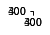

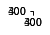

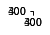

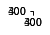

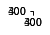

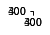

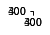

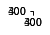

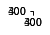

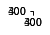

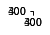

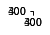

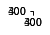

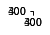

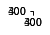

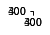

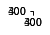

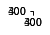

In [5]:
all_important_2d_hb_propensities=[]
all_important_2d_hb_propensities_symmetric=[]
for i in range(1,len(systems)):
    sub=[]
    sub2=[]
    for j in range(len(systems[i])):
        
        #select the current systems hbond df
        tdf = hbondDFs[i][j]
        #remove equilibration period
        eqtdf = tdf[tdf["frame"]>EQPOINT]


        # remove any h bonds to solvent etc.
        importanttdf_protein_only = eqtdf[
                                   (eqtdf["donor_resname"]!="SOL") &
                                   (eqtdf["donor_resname"]!="ETHOX") &
                                   (eqtdf["donor_resname"]!="CL") &
                                   (eqtdf["donor_resname"]!="NA") & 
                                   (eqtdf["acceptor_resname"]!="SOL") &
                                   (eqtdf["acceptor_resname"]!="ETHOX") &
                                   (eqtdf["acceptor_resname"]!="CL") &
                                   (eqtdf["acceptor_resname"]!="NA") 
                                    ]


        figure(figsize = (0,0))
        #coutn the number (2d) of hbond occurences
        a=hist2d(importanttdf_protein_only.donor_resid,importanttdf_protein_only.acceptor_resid,bins = arange(huresids[0] - 0.5,huresids[-1]+.5,1))
        hbondcounts = a[0]
        propensitybyRes = a[0]/(max(importanttdf_protein_only.frame)-EQPOINT)    
        
        symmetric_2d_hbonds = zeros((len(huresids),len(huresids)))
        for en in range(len(importanttdf_protein_only)):
            dr = int(importanttdf_protein_only["donor_resid"].iloc[en])
            ar = int(importanttdf_protein_only["acceptor_resid"].iloc[en])
            symmetric_2d_hbonds[dr-290,ar-290]+=1
            symmetric_2d_hbonds[ar-290,dr-290]+=1
        symmetric_2d_hbonds_avg = symmetric_2d_hbonds/((max(importanttdf_protein_only.frame)-EQPOINT))
            
            



        sub.append(propensitybyRes)
        sub2.append(symmetric_2d_hbonds_avg)
    all_important_2d_hb_propensities.append(sub)
    all_important_2d_hb_propensities_symmetric.append(sub2)

In [6]:
system_names = ["rhT5A","T5A","T5AR332P"]

save("all_2d_hb_propensities_symmetric_"+system_names[0]+".npy",all_important_2d_hb_propensities_symmetric[0])
save("all_2d_hb_propensities_symmetric_"+system_names[1]+".npy",all_important_2d_hb_propensities_symmetric[1])

In [7]:
# take averages
system_avg_important_2d_hb_propensities=[]
system_sem_important_2d_hb_propensities=[]
for i in range(len(all_important_2d_hb_propensities_symmetric)):
    system_avg_important_2d_hb_propensities.append(mean(all_important_2d_hb_propensities_symmetric[i],axis = 0))
    system_sem_important_2d_hb_propensities.append(scipy.stats.sem(all_important_2d_hb_propensities_symmetric[i],axis =0))

    
diffmap = system_avg_important_2d_hb_propensities[1]-system_avg_important_2d_hb_propensities[0]
diffsem = sqrt(system_sem_important_2d_hb_propensities[1]**2 + system_sem_important_2d_hb_propensities[0]**2)



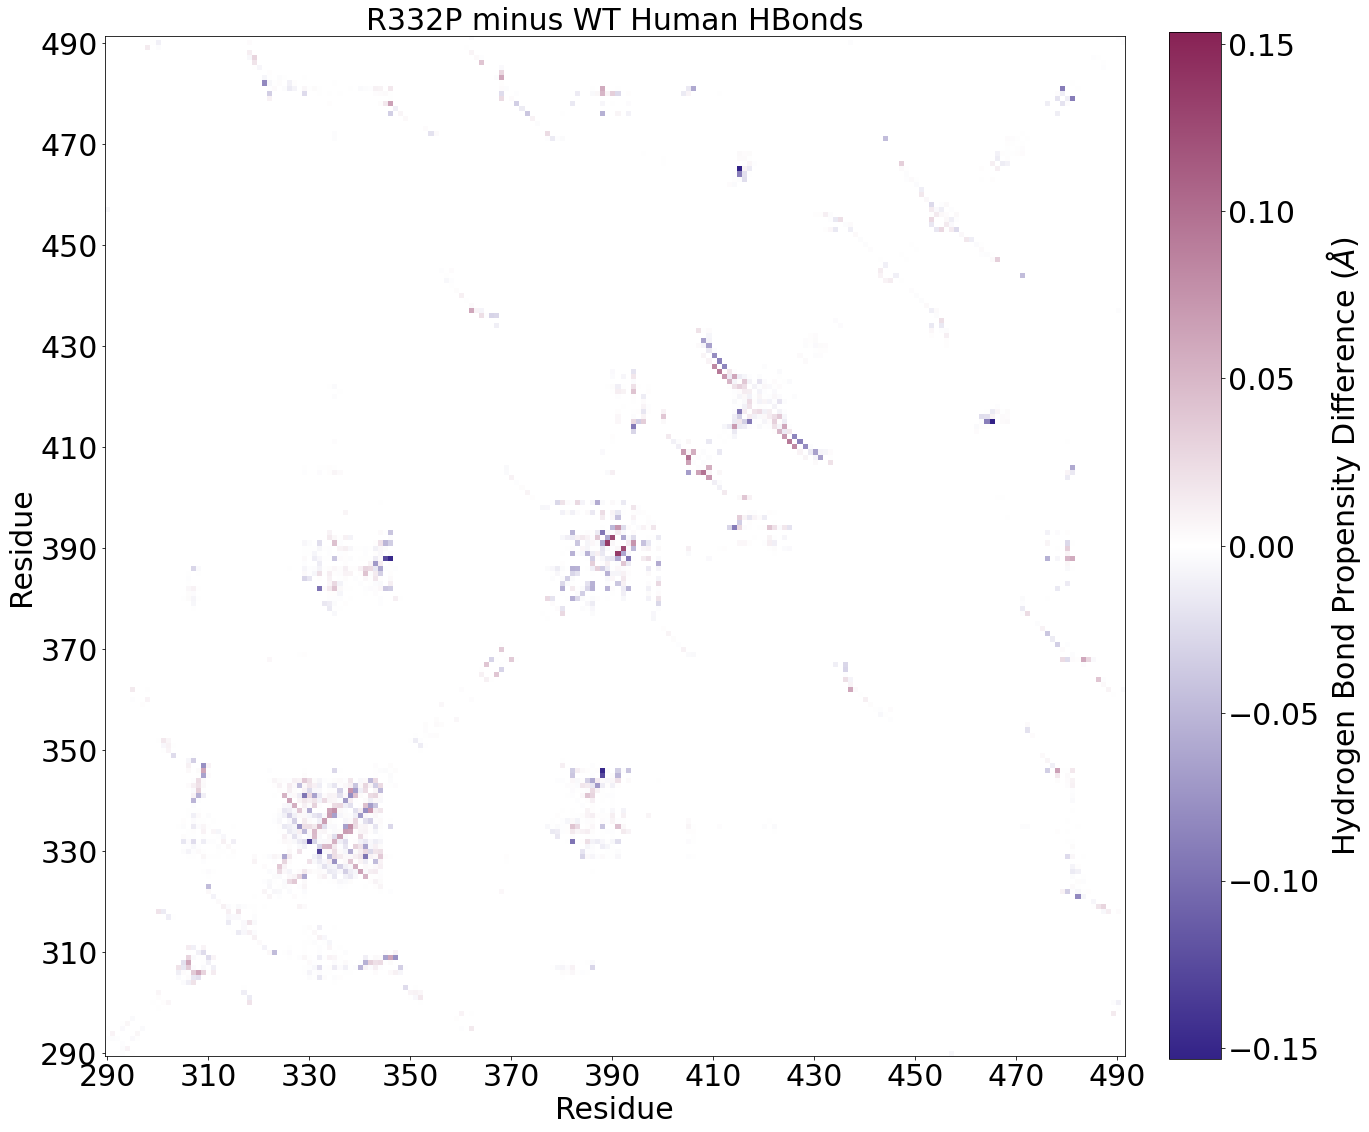

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 1000)
newcolors = viridis(np.linspace(0, 1, 1000))
#This is what you pick
rs = concatenate([linspace(51,256,500),linspace(256,136,500)])/256
gs = concatenate([linspace(34,256,500),linspace(256,34,500)])/256
bs = concatenate([linspace(136,256,500),linspace(256,85,500)])/256
newColours = []
for i in range(len(rs)):
    newColours.append([rs[i],gs[i],bs[i],1])
newcolors = newColours
newcmp = ListedColormap(newcolors)
# K the peg colour we are usingn is: #882255   -   rgb(136, 34, 85)
#andthe nopegcolour we ar eusing is: #332288   -   rgb(51, 34, 136)


dr = max(abs(diffmap.flatten()))


figure(figsize = (20,20))
imshow(diffmap.T,origin = "lower",cmap = newcmp,vmax = dr,vmin = -dr)
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Hydrogen Bond Propensity Difference ($\AA$)",fontsize = 30)
title("R332P minus WT Human HBonds",fontsize = 30)

xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
_=xticks(arange(len(arange(290,492)))[::20],arange(290,492)[::20],fontsize = 30)
_=yticks(arange(len(arange(290,492)))[::20],arange(290,492)[::20],fontsize = 30)


(35.0, 60.0)

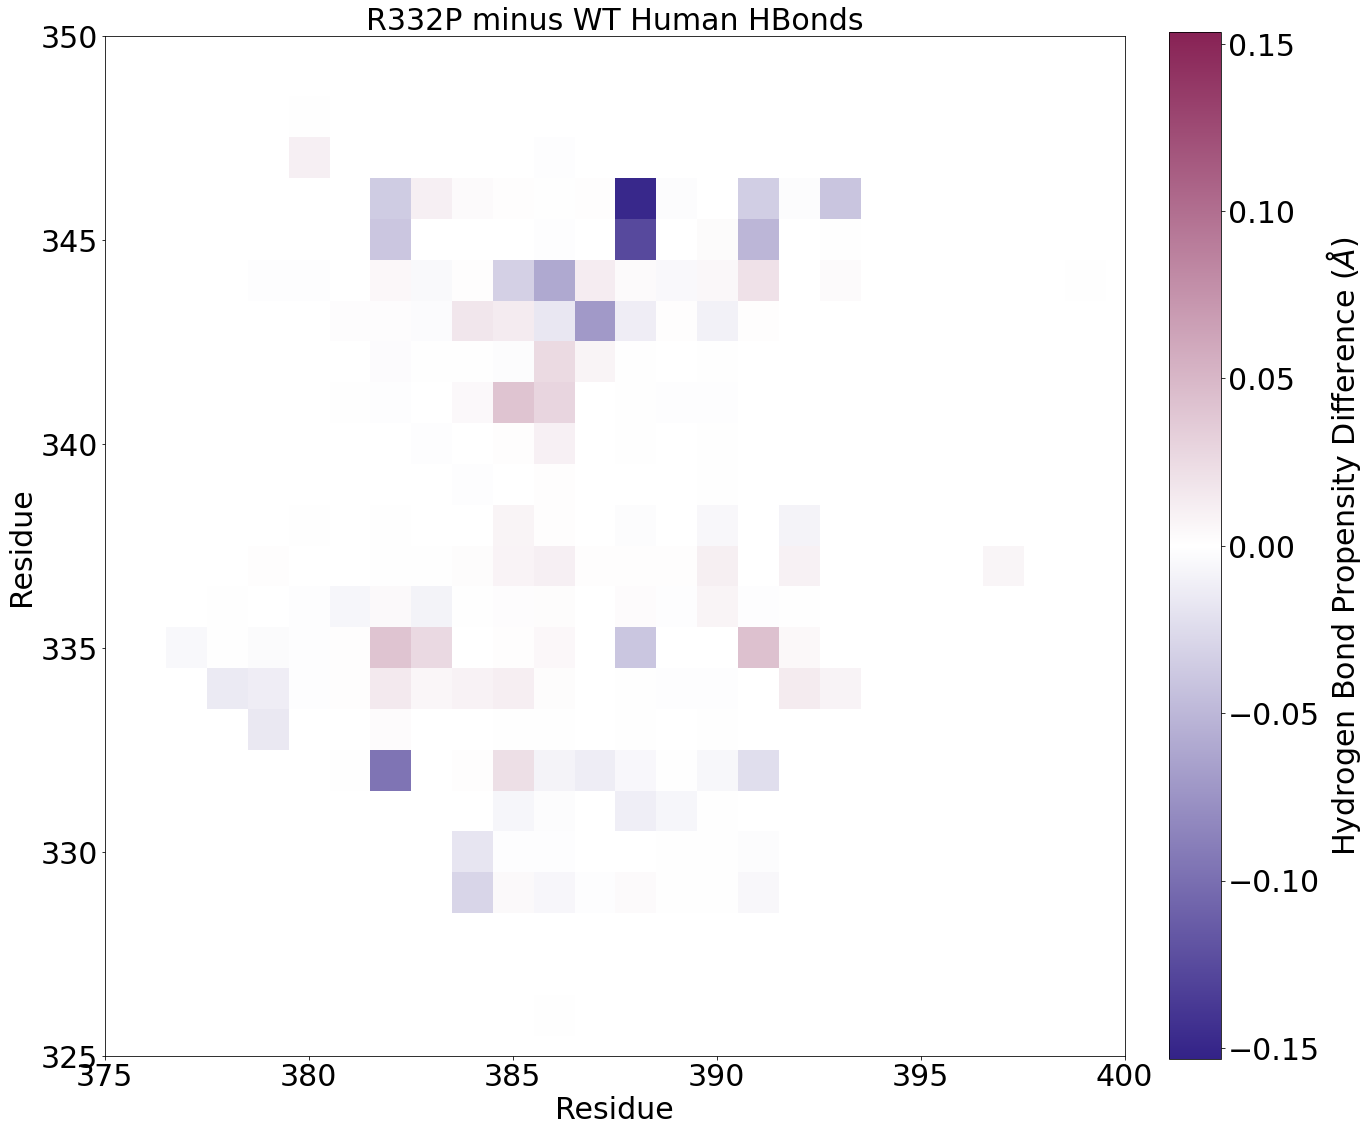

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 1000)
newcolors = viridis(np.linspace(0, 1, 1000))
#This is what you pick
rs = concatenate([linspace(51,256,500),linspace(256,136,500)])/256
gs = concatenate([linspace(34,256,500),linspace(256,34,500)])/256
bs = concatenate([linspace(136,256,500),linspace(256,85,500)])/256
newColours = []
for i in range(len(rs)):
    newColours.append([rs[i],gs[i],bs[i],1])
newcolors = newColours
newcmp = ListedColormap(newcolors)
# K the peg colour we are usingn is: #882255   -   rgb(136, 34, 85)
#andthe nopegcolour we ar eusing is: #332288   -   rgb(51, 34, 136)


dr = max(abs(diffmap.flatten()))


figure(figsize = (20,20))
imshow(diffmap.T,origin = "lower",cmap = newcmp,vmax = dr,vmin = -dr)
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
cbar.set_label("Hydrogen Bond Propensity Difference ($\AA$)",fontsize = 30)
title("R332P minus WT Human HBonds",fontsize = 30)

xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
_=xticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)
_=yticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)


xlim(375-290,400-290)
ylim(325-290,350-290)

(35.0, 60.0)

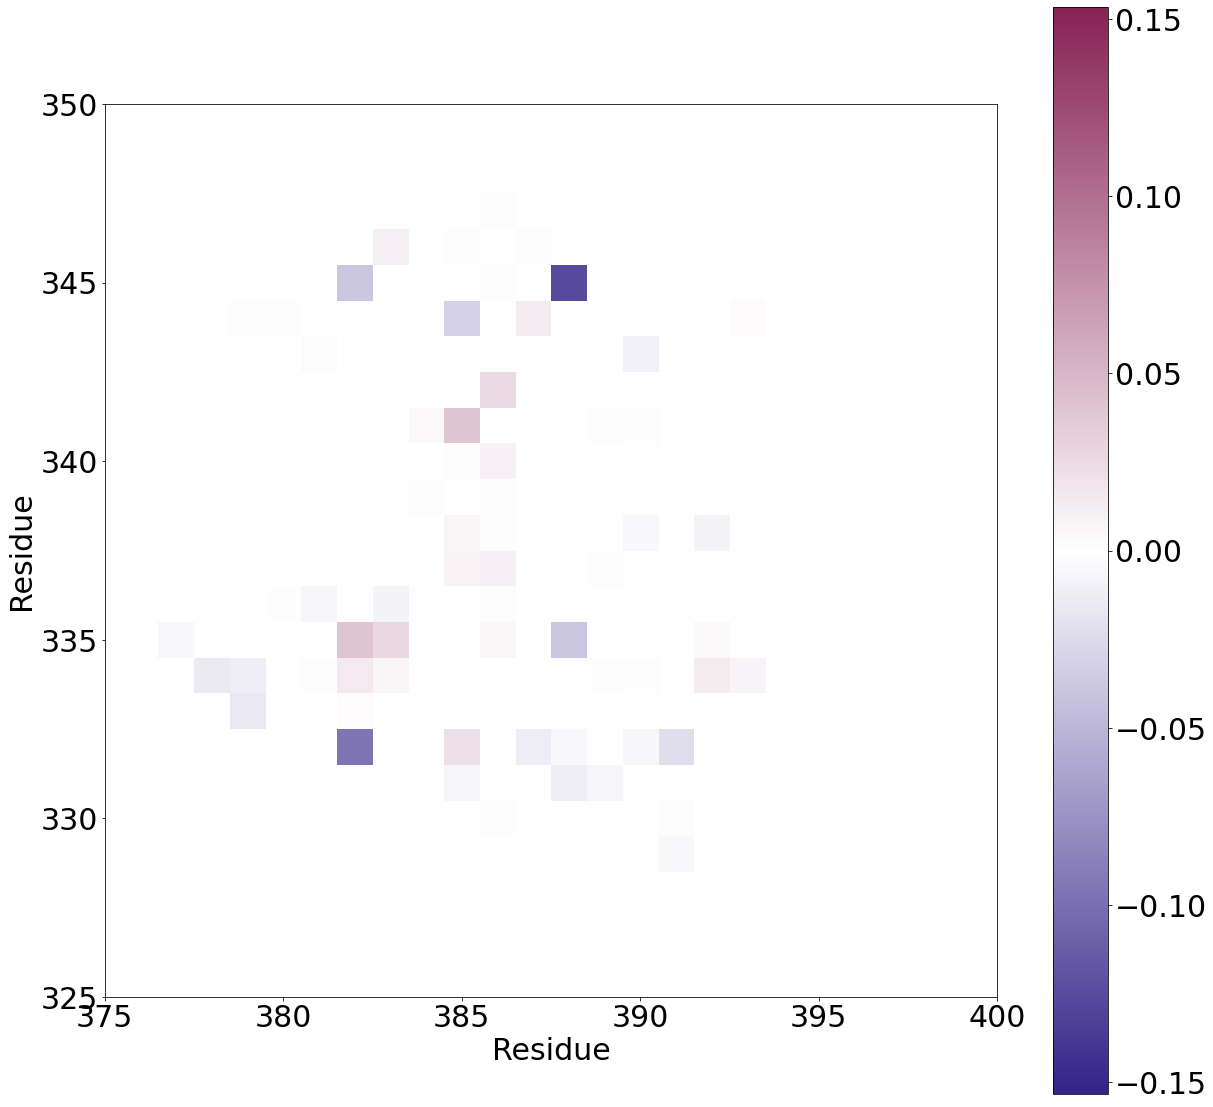

In [55]:
significant_diffbars=copy(diffmap)
for i in range(len(diffmap)):
    for j in range(len(diffmap[i])):

        
        if abs(diffsem[i][j]) > abs(diffmap[i][j]):
            significant_diffbars[i][j] = 0
            #semDiffBars[i] = 0
       
    
        
drange = max(abs(significant_diffbars).flatten())

figure(figsize = (20,20))
imshow(significant_diffbars,origin = "lower",cmap=newcmp,vmin=-drange,vmax=drange)#,extent = (resids_proper[0]-0.5,resids_proper[-1]+0.5,resids_proper[0]-0.5,resids_proper[-1]+0.5))

#5.55.55.5
cbar=colorbar()
cbar.ax.tick_params(labelsize=30) 
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
_=xticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)
_=yticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)

xlim(375-290,400-290)
ylim(325-290,350-290)

(35.0, 60.0)

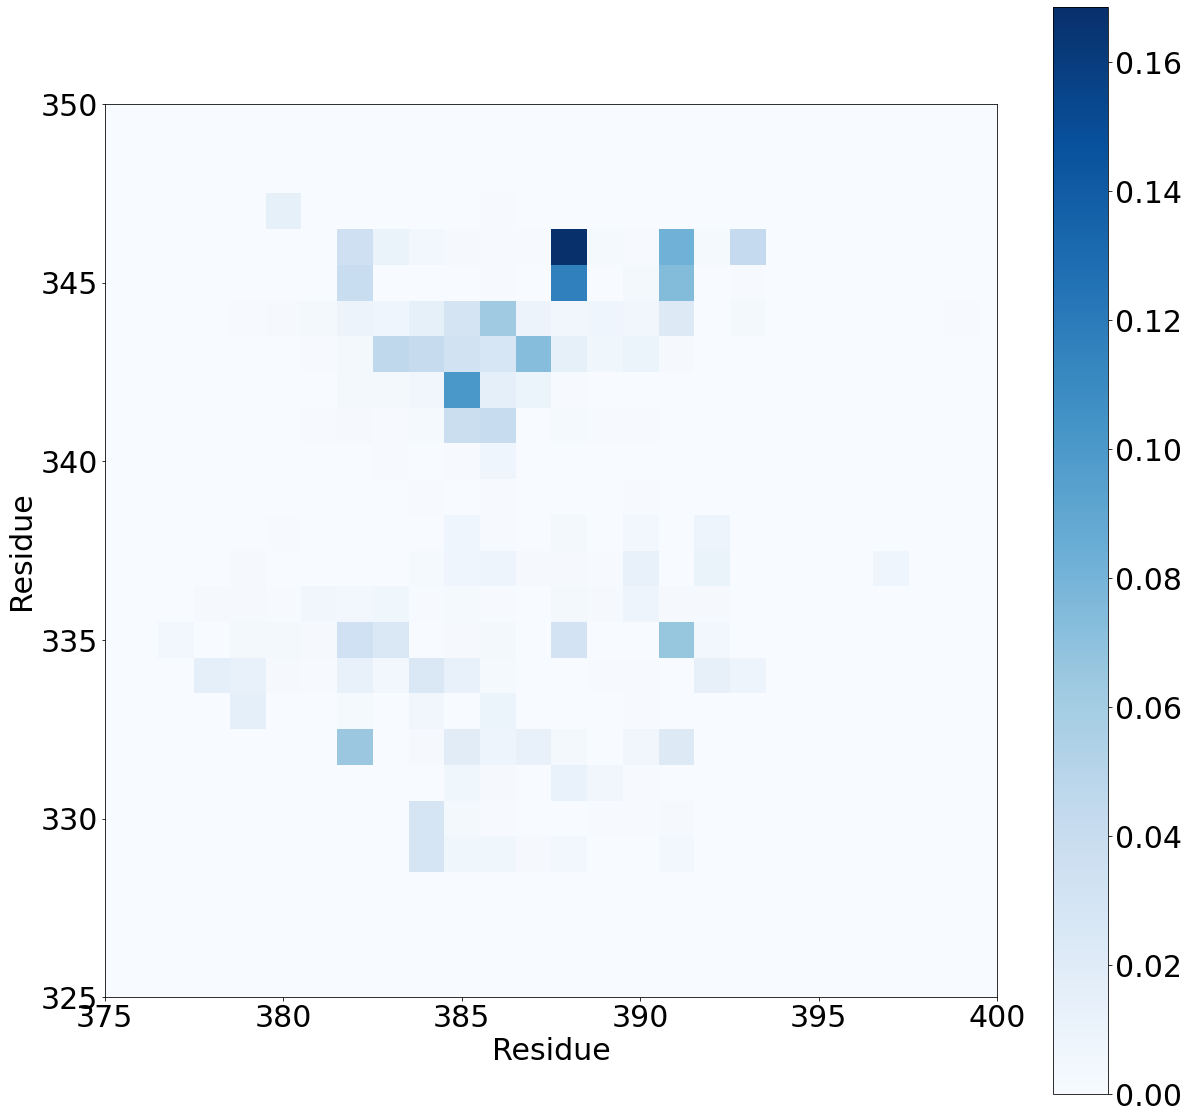

In [61]:
drange = max(abs(diffsem).flatten())

figure(figsize = (20,20))
imshow(diffsem,origin = "lower",cmap='Blues',vmin=0,vmax=drange)#,extent = (resids_proper[0]-0.5,resids_proper[-1]+0.5,resids_proper[0]-0.5,resids_proper[-1]+0.5))

#5.55.55.5
cbar=colorbar()
cbar.ax.tick_params(labelsize=30) 
xlabel("Residue",fontsize = 30)
ylabel("Residue",fontsize = 30)
_=xticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)
_=yticks(arange(len(arange(290,492)))[::5],arange(290,492)[::5],fontsize = 30)

xlim(375-290,400-290)
ylim(325-290,350-290)

0.01450000000000018